### **Sistema Inteligente de Triagem em Pronto-Socorro**
##Equipe:
##Bruno Henrique Pacheco Prudêncio - 587906
##Matheus Alves Cavalcante - 579229

# **Rede Bayesiana**

In [ ]:
!pip install pgmpy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

import heapq
import pgmpy
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination
from pgmpy.parameter_estimator import DiscreteMLE, DiscreteBayesianEstimator
from pgmpy.estimators import BayesianEstimator


import kagglehub
import os

# ============================================================
# DOWNLOAD DO DATASET
# ============================================================
# O conjunto de dados contém registros reais de pacientes
# atendidos em um serviço de emergência.
#
# Ele será utilizado para estimar automaticamente as
# probabilidades condicionais da Rede Bayesiana.
# ============================================================
path = kagglehub.dataset_download("ilkeryildiz/emergency-service-triage-application")

print("Path to dataset files:", path)
print(os.listdir(path))

Using Colab cache for faster access to the 'emergency-service-triage-application' dataset.
Path to dataset files: /kaggle/input/emergency-service-triage-application
['data.csv']


In [ ]:
df = pd.read_csv(f"{path}/data.csv", encoding='latin1', sep=';')

print(df.head())
print(df.columns)
print(df.columns.tolist())

   Group  Sex  Age  Patients number per hour  Arrival mode  Injury  \
0      2    2   71                         3             3       2   
1      1    1   56                        12             3       2   
2      2    1   68                         8             2       2   
3      1    2   71                         8             1       1   
4      1    2   58                         4             3       1   

       Chief_complain  Mental  Pain NRS_pain  ...    BT Saturation KTAS_RN  \
0   right ocular pain       1     1        2  ...  36.6        100       2   
1  right forearm burn       1     1        2  ...  36.5        NaN       4   
2        arm pain, Lt       1     1        2  ...  36.6         98       4   
3     ascites tapping       1     1        3  ...  36.5        NaN       4   
4     distension, abd       1     1        3  ...  36.5        NaN       4   

                                Diagnosis in ED Disposition KTAS_expert  \
0                              Corn

In [ ]:
def visualizar_rede(modelo, titulo="Rede Bayesiana"):
    plt.figure(figsize=(10, 6))
    pos = nx.circular_layout(modelo)
    nx.draw_networkx_nodes(modelo, pos, node_color='lightblue', node_size=2200)
    nx.draw_networkx_edges(modelo, pos, edge_color='gray', arrows=True,
                           arrowstyle='-|>', arrowsize=20, node_size=2200)
    nx.draw_networkx_labels(modelo, pos, font_size=12, font_weight='bold')
    plt.title(titulo, fontsize=16, fontweight='bold')
    plt.axis('off'); plt.tight_layout(); plt.show()

In [ ]:
# ============================================================
# DISCRETIZAÇÃO DAS VARIÁVEIS
# ============================================================
# A Rede Bayesiana utilizada é discreta.
#
# Portanto os sinais vitais são convertidos para estados
# binários:
#
# Febre:
# 0 -> temperatura normal
# 1 -> febre
#
# Saturação:
# 0 -> normal
# 1 -> baixa
#
# Pressão arterial:
# 0 -> normal
# 1 -> hipotensão
# ============================================================

def febre_estado(x):
    if pd.isna(x):
        return np.nan
    elif x < 37.5:
        return 0   # sem febre
    else:
        return 1   # febre

# Saturação
def sat_estado(x):
    if pd.isna(x):
        return np.nan
    elif x >= 95:
        return 0   # normal
    else:
        return 1   # alterada

# Pressão sistólica
def pa_estado(x):
    if pd.isna(x):
        return np.nan
    elif x >= 100:
        return 0   # normal
    else:
        return 1   # baixa

def classificar_risco(g):
    if g == 0:
        return 0   # baixo
    elif g == 1:
        return 1   # médio
    else:
        return 2   # alto


Nós: ['Febre', 'Gravidade', 'SaturacaoO2', 'PressaoArterial', 'RiscoDeterioracao']
Arestas: [('Febre', 'Gravidade'), ('Gravidade', 'RiscoDeterioracao'), ('SaturacaoO2', 'Gravidade'), ('PressaoArterial', 'Gravidade')]


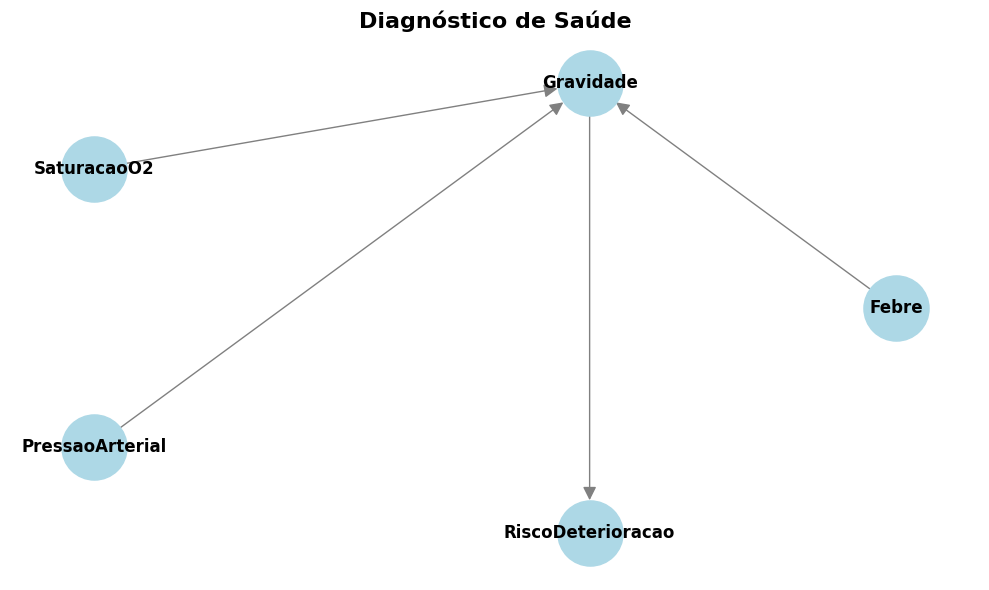

In [ ]:
# ==========================
# CRIAÇÃO DAS VARIÁVEIS
# ==========================

df['Febre'] = pd.to_numeric(
    df['BT'], errors='coerce'
).apply(febre_estado)

df['SaturacaoO2'] = pd.to_numeric(
    df['Saturation'], errors='coerce'
).apply(sat_estado)

df['PressaoArterial'] = pd.to_numeric(
    df['SBP'], errors='coerce'
).apply(pa_estado)


# ============================================================
# VARIÁVEL ALVO
# ============================================================
# A variável Gravidade é criada a partir da classificação KTAS
# existente no banco de dados.
#
# KTAS 1 e 2 -> Gravidade Alta
# KTAS 3     -> Gravidade Média
# KTAS 4 e 5 -> Gravidade Baixa
# ============================================================

def classificar_gravidade(ktas):
    if ktas <= 2:
        return 2   # alta
    elif ktas == 3:
        return 1   # média
    else:
        return 0   # baixa

df['Gravidade'] = df['KTAS_RN'].apply(classificar_gravidade)
# Probabilidade maior de doença crônica em idosos

df['RiscoDeterioracao'] = df['Gravidade'].apply(classificar_risco)

modelo_triagem = DiscreteBayesianNetwork([
    ('Febre', 'Gravidade'),
    ('SaturacaoO2', 'Gravidade'),
    ('PressaoArterial', 'Gravidade'),
    ('Gravidade', 'RiscoDeterioracao')
])

print("Nós:", modelo_triagem.nodes())
print("Arestas:", modelo_triagem.edges())
visualizar_rede(modelo_triagem, "Diagnóstico de Saúde")
# ============================================================
# ESTRUTURA DA REDE BAYESIANA
# ============================================================
#
# Febre ------------\
# Saturação ---------> Gravidade ------> RiscoDeterioracao
# Pressão ----------/
#
# A hipótese adotada é que os sinais vitais influenciam a
# gravidade clínica do paciente.
#
# A gravidade, por sua vez, determina o risco de deterioração.
# ============================================================

In [ ]:
combinacoes = (
    df.groupby(
        ['Febre', 'SaturacaoO2', 'PressaoArterial']
    )
    .size()
    .reset_index(name='Quantidade')
)

print(combinacoes)

   Febre  SaturacaoO2  PressaoArterial  Quantidade
0    0.0          0.0              0.0         491
1    0.0          0.0              1.0          11
2    0.0          1.0              0.0          37
3    0.0          1.0              1.0           7
4    1.0          0.0              0.0          16
5    1.0          0.0              1.0           3
6    1.0          1.0              0.0           2


In [ ]:
dados_rede0 = df[
    [
        'Febre',
        'SaturacaoO2',
        'PressaoArterial',
        'Gravidade',
        'RiscoDeterioracao'
    ]
].dropna()

# ============================================================
# CASOS SINTÉTICOS
# ============================================================
#
# O banco de dados possui poucos pacientes extremamente graves.
#
# Para evitar probabilidades muito pequenas nesses casos,
# adicionamos alguns exemplos sintéticos representando pacientes
# críticos.
#
# Isso torna o treinamento da Rede Bayesiana mais robusto.
# ============================================================
casos_sinteticos = pd.DataFrame({
    'Febre': [1]*10,
    'SaturacaoO2': [1]*10,
    'PressaoArterial': [1]*10,
    'Gravidade': [2]*10,           # alta gravidade
    'RiscoDeterioracao': [2]*10
})

# ============================================================
# TREINAMENTO DA REDE
# ============================================================
#
# Utiliza o estimador Bayesiano (BDeu).
#
# Diferentemente da máxima verossimilhança, esse estimador
# evita probabilidades iguais a zero quando determinadas
# combinações aparecem poucas vezes no banco.
# ============================================================
dados_rede1 = pd.concat(
    [dados_rede0, casos_sinteticos],
    ignore_index=True
)

bayesian_estimator = BayesianEstimator(
    modelo_triagem,
    dados_rede1
)

cpds = bayesian_estimator.get_parameters(
    prior_type="BDeu",
    equivalent_sample_size=10
)

modelo_triagem.cpds = []
modelo_triagem.add_cpds(*cpds)

print(modelo_triagem.check_model())

for cpd in modelo_triagem.get_cpds():
    print(cpd)


True
+------------+-----------+
| Febre(0.0) | 0.938671  |
+------------+-----------+
| Febre(1.0) | 0.0613288 |
+------------+-----------+
+-----------------+-----+----------------------+
| Febre           | ... | Febre(1.0)           |
+-----------------+-----+----------------------+
| PressaoArterial | ... | PressaoArterial(1.0) |
+-----------------+-----+----------------------+
| SaturacaoO2     | ... | SaturacaoO2(1.0)     |
+-----------------+-----+----------------------+
| Gravidade(0)    | ... | 0.03703703703703704  |
+-----------------+-----+----------------------+
| Gravidade(1)    | ... | 0.03703703703703704  |
+-----------------+-----+----------------------+
| Gravidade(2)    | ... | 0.9259259259259258   |
+-----------------+-----+----------------------+
+----------------------+-----+----------------------+
| Gravidade            | ... | Gravidade(2)         |
+----------------------+-----+----------------------+
| RiscoDeterioracao(0) | ... | 0.007199424046076314 |
+------

/tmp/ipykernel_405/3509842500.py:46: FutureWarning: `pgmpy.estimators.BayesianEstimator` is deprecated and will be removed in v1.3.0. Please use `pgmpy.parameter_estimator.DiscreteBayesianEstimator` instead.
  bayesian_estimator = BayesianEstimator(


In [ ]:
# ============================================================
# TESTE DA REDE
# ============================================================
#
# São realizadas consultas na Rede Bayesiana utilizando
# diferentes combinações de sinais vitais.
#
# O objetivo é verificar como a probabilidade de Gravidade
# muda conforme as evidências observadas.
# ============================================================
infer = VariableElimination(modelo_triagem)

for evid in [
    {'Febre':0,'SaturacaoO2':0,'PressaoArterial':0},
    {'Febre':0,'SaturacaoO2':1,'PressaoArterial':0},
    {'Febre':0,'SaturacaoO2':1,'PressaoArterial':1},
    {'Febre':1,'SaturacaoO2':1,'PressaoArterial':1}
]:
    print("\nEvidência:", evid)

    resultado = infer.query(
        variables=['Gravidade'],
        evidence={
            'Febre': evid['Febre'],
            'SaturacaoO2': evid['SaturacaoO2'],
            'PressaoArterial': evid['PressaoArterial']
        }
    )

    print(resultado)


Evidência: {'Febre': 0, 'SaturacaoO2': 0, 'PressaoArterial': 0}
+--------------+------------------+
| Gravidade    |   phi(Gravidade) |
+==============+==================+
| Gravidade(0) |           0.4539 |
+--------------+------------------+
| Gravidade(1) |           0.3137 |
+--------------+------------------+
| Gravidade(2) |           0.2324 |
+--------------+------------------+

Evidência: {'Febre': 0, 'SaturacaoO2': 1, 'PressaoArterial': 0}
+--------------+------------------+
| Gravidade    |   phi(Gravidade) |
+==============+==================+
| Gravidade(0) |           0.0893 |
+--------------+------------------+
| Gravidade(1) |           0.4815 |
+--------------+------------------+
| Gravidade(2) |           0.4292 |
+--------------+------------------+

Evidência: {'Febre': 0, 'SaturacaoO2': 1, 'PressaoArterial': 1}
+--------------+------------------+
| Gravidade    |   phi(Gravidade) |
+==============+==================+
| Gravidade(0) |           0.0505 |
+------------

# **Implementação do A Estrela**

In [ ]:
# ============================================================
# CLASSE PACIENTE
# ============================================================
#
# Cada paciente possui:
#
# • sintomas discretizados;
# • tempo inicial de espera;
# • probabilidade de Gravidade Alta calculada pela Rede;
# • função para calcular o risco dinâmico de deterioração.
#
# ============================================================
class Paciente:

    def __init__(
        self,
        id_paciente,
        nome,
        febre,
        sat,
        pa,
        tempo_espera_inicial
    ):

        self.id = id_paciente
        self.nome = nome

        self.febre = febre
        self.sat = sat
        self.pa = pa

        self.tempo_espera_inicial = tempo_espera_inicial

        self.p_alta = self.calcular_probabilidade_alta()

    def calcular_probabilidade_alta(self):
# Consulta a Rede Bayesiana para calcular
# P(Gravidade = Alta | evidências)
        evidence = {
            'Febre': self.febre,
            'SaturacaoO2': self.sat,
            'PressaoArterial': self.pa
        }
        resultado = infer.query(variables=['Gravidade'], evidence=evidence)
        return resultado.values[2]

    def calcular_risco_de_deterioracao(self, tempo_simulado, tau=45):
        """
        Calcula o risco dinâmico: P(Alta) * e^(tempo_total / tau)
        tau controla a velocidade da curva exponencial.
        """
        tempo_total = self.tempo_espera_inicial + tempo_simulado
        return self.p_alta * np.exp(tempo_total / tau)

# O risco aumenta exponencialmente conforme o tempo de espera.
#
# risco = P(Alta) * e^(tempo/tau)
#
# Dessa forma, pacientes graves que aguardam muito tempo
# tornam-se cada vez mais prioritários.

In [ ]:
# ============================================================
# ESTADO DA BUSCA A*
# ============================================================
#
# Cada nó da árvore representa uma possível sequência parcial
# de atendimentos.
#
# O estado armazena:
#
# • pacientes ainda aguardando;
# • ordem construída até o momento;
# • custo acumulado g(n);
# • heurística h(n);
# • valor f(n)=g(n)+h(n).
# ============================================================
class EstadoFila:
    def __init__(self, pacientes_restantes, ordem_atendimento=None, g_custo=0, tempo_passado=0):
        self.pacientes = pacientes_restantes  # Lista de pacientes ainda na fila nesta projeção
        self.ordem_atendimento = ordem_atendimento if ordem_atendimento is not None else []
        self.g = g_custo  # Custo real acumulado (sofrimento dos pacientes que esperaram)
        self.tempo_passado = tempo_passado  # Tempo fictício que passou dentro da árvore de busca
        self.h = self.calcular_heuristica()
        self.f = self.g + self.h

    def calcular_heuristica(self):
      # A heurística estima o risco futuro considerando todos
# os pacientes que ainda permanecem na fila.
#
# Quanto maior esse valor, pior tende a ser aquela sequência.
        return sum(
        p.calcular_risco_de_deterioracao(self.tempo_passado)
        for p in self.pacientes)

    def __lt__(self, outro):
        # Necessário para a fila de prioridades (heapq) escolher sempre o menor f(n)
        return self.f < outro.f

In [ ]:

# ============================================================
# ALGORITMO A*
# ============================================================
#
# Objetivo:
#
# Encontrar a sequência de atendimento que minimize
# o risco acumulado dos pacientes.
#
# A função de avaliação utilizada é:
#
# f(n)=g(n)+h(n)
#
# onde:
#
# g(n) -> risco acumulado já gerado;
# h(n) -> estimativa do risco restante.
# ============================================================

BEAM_WIDTH = 100

def encontrar_agenda_otica_a_estrela(lista_pacientes):
    estado_inicial = EstadoFila(lista_pacientes)
    prio_queue = [estado_inicial]

    while prio_queue:
        estado_atual = heapq.heappop(prio_queue)

        # Objetivo: todos os pacientes foram atendidos
        if not estado_atual.pacientes:
            return estado_atual.ordem_atendimento

        # Gera os estados sucessores
        for i, paciente_escolhido in enumerate(estado_atual.pacientes):

            nova_fila = (
                estado_atual.pacientes[:i]
                + estado_atual.pacientes[i+1:]
            )

            # Cada atendimento leva 10 minutos
            novo_tempo = estado_atual.tempo_passado + 10

            # Custo causado pelos pacientes que continuam esperando
            custo_passo = sum(
                p.calcular_risco_de_deterioracao(novo_tempo)
                for p in nova_fila
            )

            novo_g = estado_atual.g + custo_passo

            nova_ordem = (
                estado_atual.ordem_atendimento
                + [paciente_escolhido]
            )

            proximo_estado = EstadoFila(
                pacientes_restantes=nova_fila,
                ordem_atendimento=nova_ordem,
                g_custo=novo_g,
                tempo_passado=novo_tempo
            )

            heapq.heappush(prio_queue, proximo_estado)
# ============================================================
# BEAM SEARCH
# ============================================================
#
# O espaço de busca cresce com n!.
#
# Para tornar possível resolver cenários maiores,
# limita-se a fronteira aos melhores estados.
#
# Essa estratégia aproxima o A* e reduz drasticamente
# o custo computacional.
# ============================================================

        if len(prio_queue) > BEAM_WIDTH:
            prio_queue = heapq.nsmallest(BEAM_WIDTH, prio_queue)
            heapq.heapify(prio_queue)

    return None

In [ ]:
if __name__ == "__main__":
    print("\n--- Simulando a Entrada de Pacientes no Pronto Socorro ---")

    # Criando 5 pacientes com os estados de sintomas [Febre, Sat, PA]

    fila_hospital_5 = [

        Paciente(1, "Lucas (Grave)", febre=1, sat=1, pa=1, tempo_espera_inicial=0),

        Paciente(2, "João (Moderado)", febre=0, sat=1, pa=1, tempo_espera_inicial=60),

        Paciente(3, "Maria (Leve)", febre=0, sat=0, pa=0, tempo_espera_inicial=20),

        Paciente(4, "Ana (Grave)", febre=1, sat=1, pa=0, tempo_espera_inicial=15),

        Paciente(5, "Carlos (Moderado)", febre=1, sat=0, pa=1, tempo_espera_inicial=40)
    ]
    # Criando 20 pacientes com os estados de sintomas [Febre, Sat, PA]
    fila_hospital_20 = [

        Paciente(1, "Lucas", 1,1,1,0),
        Paciente(2, "João", 0,1,1,60),
        Paciente(3, "Maria",0,0,0,20),
        Paciente(4, "Ana",1,1,0,15),
        Paciente(5, "Carlos",1,0,1,40),
        Paciente(6, "Fernanda",0,0,1,10),
        Paciente(7, "Pedro",1,0,0,35),
        Paciente(8, "Marcos",0,1,0,45),
        Paciente(9, "Paula",1,1,1,5),
        Paciente(10,"José",0,0,0,70),
        Paciente(11,"Ricardo",1,0,1,25),
        Paciente(12,"Patrícia",0,1,1,55),
        Paciente(13,"Gabriel",1,1,0,30),
        Paciente(14,"Juliana",0,0,1,18),
        Paciente(15,"Roberto",1,0,0,50),
        Paciente(16,"Larissa",0,1,0,12),
        Paciente(17,"Renato",1,1,1,8),
        Paciente(18,"Bianca",0,0,0,90),
        Paciente(19,"Eduardo",1,0,1,65),
        Paciente(20,"Camila",0,1,0,28)
    ]


    print(f"Calculando ordem de chamada via A*...")
    ordem_final_5 = encontrar_agenda_otica_a_estrela(fila_hospital_5)
    ordem_final_20 = encontrar_agenda_otica_a_estrela(fila_hospital_20)

print("\n========== CENÁRIO 5 PACIENTES ==========")

for pos, paciente in enumerate(ordem_final_5, start=1):
    current_risco = paciente.calcular_risco_de_deterioracao(0)
    print(
        f"{pos}º Lugar: {paciente.nome} "
        f"| P(Alta)={paciente.p_alta:.2%} "
        f"| Espera={paciente.tempo_espera_inicial} min "
        f"| Risco={current_risco:.4f}"
    )

print("\n========== CENÁRIO 20 PACIENTES ==========")

for pos, paciente in enumerate(ordem_final_20, start=1):
    current_risco = paciente.calcular_risco_de_deterioracao(0)
    print(
        f"{pos}º Lugar: {paciente.nome} "
        f"| P(Alta)={paciente.p_alta:.2%} "
        f"| Espera={paciente.tempo_espera_inicial} min "
        f"| Risco={current_risco:.4f}"
    )

#O cenário de 20 pacientes tem 20! ≈ 2,43 × 10¹⁸ ordens tornando ele inviável para o A estrela, por isso foi limitado para 100 estados



--- Simulando a Entrada de Pacientes no Pronto Socorro ---
Calculando ordem de chamada via A*...

========== CENÁRIO 5 PACIENTES ==========
1º Lugar: João (Moderado) | P(Alta)=65.66% | Espera=60 min | Risco=2.4908
2º Lugar: Lucas (Grave) | P(Alta)=92.59% | Espera=0 min | Risco=0.9259
3º Lugar: Carlos (Moderado) | P(Alta)=33.33% | Espera=40 min | Risco=0.8108
4º Lugar: Ana (Grave) | P(Alta)=43.59% | Espera=15 min | Risco=0.6083
5º Lugar: Maria (Leve) | P(Alta)=23.24% | Espera=20 min | Risco=0.3625

========== CENÁRIO 20 PACIENTES ==========
1º Lugar: João | P(Alta)=65.66% | Espera=60 min | Risco=2.4908
2º Lugar: Patrícia | P(Alta)=65.66% | Espera=55 min | Risco=2.2289
3º Lugar: Bianca | P(Alta)=23.24% | Espera=90 min | Risco=1.7175
4º Lugar: Eduardo | P(Alta)=33.33% | Espera=65 min | Risco=1.4132
5º Lugar: Marcos | P(Alta)=42.92% | Espera=45 min | Risco=1.1667
6º Lugar: Renato | P(Alta)=92.59% | Espera=8 min | Risco=1.1061
7º Lugar: José | P(Alta)=23.24% | Espera=70 min | Risco=1.1012


# **Implementação da FILA**



In [ ]:
import collections
# ============================================================
# FILA FIFO
# ============================================================
#
# Implementação da fila tradicional.
#
# Os pacientes são atendidos exatamente na ordem
# de chegada.
#
# Essa estratégia será utilizada como baseline
# para comparação com os algoritmos inteligentes.
# ============================================================
class FilaDeAtendimento:
    def __init__(self, initial_patients=None):
        self.pacientes = collections.deque()

        if initial_patients is not None:
            for paciente in initial_patients:
                self.pacientes.append(paciente)

    def adicionar_paciente(self, paciente):
        self.pacientes.append(paciente)
        print(f"Paciente {paciente.nome} adicionado à fila.")

    def proximo_paciente(self):
        if not self.esta_vazia():
            paciente = self.pacientes.popleft()
            print(f"Paciente {paciente.nome} atendido.")
            return paciente
        else:
            print("A fila de atendimento está vazia.")
            return None

    def esta_vazia(self):
        return len(self.pacientes) == 0

    def tamanho(self):
        return len(self.pacientes)

    def ver_fila(self):
        if not self.esta_vazia():
            print("Pacientes na fila (ordem de chegada):")
            for i, paciente in enumerate(list(self.pacientes), 1):
                print(f"  {i}. {paciente.nome}", f"| Espera={paciente.tempo_espera_inicial} min")

        else:
            print("A fila de atendimento está vazia.")

fila_hospital_5.sort(
    key=lambda p: p.tempo_espera_inicial,
    reverse=True
)

fila_hospital_20.sort(
    key=lambda p: p.tempo_espera_inicial,
    reverse=True
)

print("\n========== FILA ORIGINAL - CENÁRIO 1 (5 PACIENTES) ==========")

fila5 = FilaDeAtendimento(fila_hospital_5)

print(f"Quantidade de pacientes: {fila5.tamanho()}")
fila5.ver_fila()


print("\n========== FILA ORIGINAL - CENÁRIO 2 (20 PACIENTES) ==========")

fila20 = FilaDeAtendimento(fila_hospital_20)
print(f"Quantidade de pacientes: {fila20.tamanho()}")
fila20.ver_fila()


========== FILA ORIGINAL - CENÁRIO 1 (5 PACIENTES) ==========
Quantidade de pacientes: 5
Pacientes na fila (ordem de chegada):
  1. João (Moderado) | Espera=60 min
  2. Carlos (Moderado) | Espera=40 min
  3. Maria (Leve) | Espera=20 min
  4. Ana (Grave) | Espera=15 min
  5. Lucas (Grave) | Espera=0 min

========== FILA ORIGINAL - CENÁRIO 2 (20 PACIENTES) ==========
Quantidade de pacientes: 20
Pacientes na fila (ordem de chegada):
  1. Bianca | Espera=90 min
  2. José | Espera=70 min
  3. Eduardo | Espera=65 min
  4. João | Espera=60 min
  5. Patrícia | Espera=55 min
  6. Roberto | Espera=50 min
  7. Marcos | Espera=45 min
  8. Carlos | Espera=40 min
  9. Pedro | Espera=35 min
  10. Gabriel | Espera=30 min
  11. Camila | Espera=28 min
  12. Ricardo | Espera=25 min
  13. Maria | Espera=20 min
  14. Juliana | Espera=18 min
  15. Ana | Espera=15 min
  16. Larissa | Espera=12 min
  17. Fernanda | Espera=10 min
  18. Renato | Espera=8 min
  19. Paula | Espera=5 min
  20. Lucas | Espera=0 mi

# **Implementação da BUSCA GULOSA**



In [ ]:
# ============================================================
# BUSCA GULOSA
# ============================================================
#
# Em cada passo escolhe imediatamente o paciente
# com maior probabilidade de Gravidade Alta.
#
# Não considera o efeito futuro da decisão,
# apenas a melhor escolha local.
# ============================================================
class EstadoGuloso:
    """
    Representa um estado da busca gulosa.

    Cada estado guarda:
        - pacientes ainda aguardando;
        - ordem de atendimento construída até o momento;
        - valor da heurística h(n).
    """

    def __init__(self, pacientes_restantes, ordem_atendimento=None):

        self.pacientes = pacientes_restantes

        if ordem_atendimento is None:
            self.ordem_atendimento = []
        else:
            self.ordem_atendimento = ordem_atendimento

        # Busca Gulosa utiliza SOMENTE a heurística
        self.h = self.calcular_heuristica()

    def calcular_heuristica(self):
        """
        Heurística:

        Quanto maior a probabilidade de gravidade dos pacientes
        ainda aguardando, maior será o valor.

        Como o heapq sempre remove o MENOR elemento,
        retornamos o negativo da soma das probabilidades.
        Assim, estados com maior gravidade serão explorados primeiro.
        """

        return -sum(p.p_alta for p in self.pacientes)

    def __lt__(self, outro):
        """
        Permite que heapq compare estados.

        O estado com menor h será retirado primeiro.
        """
        return self.h < outro.h

In [ ]:
def busca_gulosa(lista_pacientes):
    """
    Busca Gulosa

    A heurística utilizada é a probabilidade de Gravidade Alta
    calculada pela Rede Bayesiana.

    Em cada passo escolhe o paciente com maior P(Alta).
    """

    # Faz uma cópia para não alterar a lista original
    pacientes_restantes = lista_pacientes.copy()

    ordem = []

    while pacientes_restantes:

        # Escolhe o paciente de maior probabilidade de gravidade
        melhor = max(
            pacientes_restantes,
            key=lambda p: p.p_alta
        )

        ordem.append(melhor)

        pacientes_restantes.remove(melhor)

    return ordem

In [ ]:
print("\n==============================")
print("BUSCA GULOSA - CENÁRIO 1 (5 PACIENTES)")
print("==============================")

ordem_gulosa_5 = busca_gulosa(fila_hospital_5)

for i, paciente in enumerate(ordem_gulosa_5, start=1):

    risco = paciente.calcular_risco_de_deterioracao(0)

    print(
        f"{i}º Lugar: {paciente.nome}"
        f" | P(Alta)={paciente.p_alta:.2%}"
        f" | Espera={paciente.tempo_espera_inicial} min"
        f" | Risco={risco:.4f}"
    )


print("\n==============================")
print("BUSCA GULOSA - CENÁRIO 2 (20 PACIENTES)")
print("==============================")

ordem_gulosa_20 = busca_gulosa(fila_hospital_20)

for i, paciente in enumerate(ordem_gulosa_20, start=1):

    risco = paciente.calcular_risco_de_deterioracao(0)

    print(
        f"{i}º Lugar: {paciente.nome}"
        f" | P(Alta)={paciente.p_alta:.2%}"
        f" | Espera={paciente.tempo_espera_inicial} min"
        f" | Risco={risco:.4f}"
    )


BUSCA GULOSA - CENÁRIO 1 (5 PACIENTES)
1º Lugar: Lucas (Grave) | P(Alta)=92.59% | Espera=0 min | Risco=0.9259
2º Lugar: João (Moderado) | P(Alta)=65.66% | Espera=60 min | Risco=2.4908
3º Lugar: Ana (Grave) | P(Alta)=43.59% | Espera=15 min | Risco=0.6083
4º Lugar: Carlos (Moderado) | P(Alta)=33.33% | Espera=40 min | Risco=0.8108
5º Lugar: Maria (Leve) | P(Alta)=23.24% | Espera=20 min | Risco=0.3625

BUSCA GULOSA - CENÁRIO 2 (20 PACIENTES)
1º Lugar: Renato | P(Alta)=92.59% | Espera=8 min | Risco=1.1061
2º Lugar: Paula | P(Alta)=92.59% | Espera=5 min | Risco=1.0347
3º Lugar: Lucas | P(Alta)=92.59% | Espera=0 min | Risco=0.9259
4º Lugar: João | P(Alta)=65.66% | Espera=60 min | Risco=2.4908
5º Lugar: Patrícia | P(Alta)=65.66% | Espera=55 min | Risco=2.2289
6º Lugar: Gabriel | P(Alta)=43.59% | Espera=30 min | Risco=0.8490
7º Lugar: Ana | P(Alta)=43.59% | Espera=15 min | Risco=0.6083
8º Lugar: Marcos | P(Alta)=42.92% | Espera=45 min | Risco=1.1667
9º Lugar: Camila | P(Alta)=42.92% | Espera=2

# **Conclusões e Resultados**



In [ ]:
# ============================================================
# RISCO ACUMULADO TOTAL
# ============================================================
#
# Calcula quanto risco foi acumulado durante toda
# a sequência de atendimento.
#
# Após cada atendimento:
#
# • o tempo aumenta;
# • todos os demais pacientes continuam esperando;
# • seus riscos aumentam.
#
# Essa métrica é utilizada para comparar as estratégias.
# ============================================================
def calcular_risco_acumulado_total(ordem_atendimento, tempo_atendimento=10):

    pacientes_restantes = ordem_atendimento.copy()

    tempo = 0
    risco_total = 0

    for paciente in ordem_atendimento:

        tempo += tempo_atendimento

        pacientes_restantes.remove(paciente)

        risco_total += sum(
            p.calcular_risco_de_deterioracao(tempo)
            for p in pacientes_restantes
        )

    return risco_total

In [ ]:
def imprimir_ordem(titulo, ordem):
    print(f"\n========== {titulo} ==========")

    for i, paciente in enumerate(ordem, start=1):
        risco_atual = paciente.calcular_risco_de_deterioracao(0)

        print(
            f"{i}º Lugar: {paciente.nome}"
            f" | P(Alta)={paciente.p_alta:.2%}"
            f" | Espera inicial={paciente.tempo_espera_inicial} min"
            f" | Risco inicial={risco_atual:.4f}"
        )

    risco_total = calcular_risco_acumulado_total(ordem)

    print(f"Risco acumulado total da estratégia: {risco_total:.4f}")

imprimir_ordem("FIFO - 8 PACIENTES", fila_hospital_5)
imprimir_ordem("BUSCA GULOSA - 8 PACIENTES", ordem_gulosa_5)
imprimir_ordem("A* EXATO - 8 PACIENTES", ordem_final_5)

imprimir_ordem("FIFO - 20 PACIENTES", fila_hospital_20)
imprimir_ordem("BUSCA GULOSA - 20 PACIENTES", ordem_gulosa_20)
imprimir_ordem("A* LIMITADO POR JANELA - 20 PACIENTES", ordem_final_20)


========== FIFO - 8 PACIENTES ==========
1º Lugar: João (Moderado) | P(Alta)=65.66% | Espera inicial=60 min | Risco inicial=2.4908
2º Lugar: Carlos (Moderado) | P(Alta)=33.33% | Espera inicial=40 min | Risco inicial=0.8108
3º Lugar: Maria (Leve) | P(Alta)=23.24% | Espera inicial=20 min | Risco inicial=0.3625
4º Lugar: Ana (Grave) | P(Alta)=43.59% | Espera inicial=15 min | Risco inicial=0.6083
5º Lugar: Lucas (Grave) | P(Alta)=92.59% | Espera inicial=0 min | Risco inicial=0.9259
Risco acumulado total da estratégia: 11.5802

========== BUSCA GULOSA - 8 PACIENTES ==========
1º Lugar: Lucas (Grave) | P(Alta)=92.59% | Espera inicial=0 min | Risco inicial=0.9259
2º Lugar: João (Moderado) | P(Alta)=65.66% | Espera inicial=60 min | Risco inicial=2.4908
3º Lugar: Ana (Grave) | P(Alta)=43.59% | Espera inicial=15 min | Risco inicial=0.6083
4º Lugar: Carlos (Moderado) | P(Alta)=33.33% | Espera inicial=40 min | Risco inicial=0.8108
5º Lugar: Maria (Leve) | P(Alta)=23.24% | Espera inicial=20 min | 

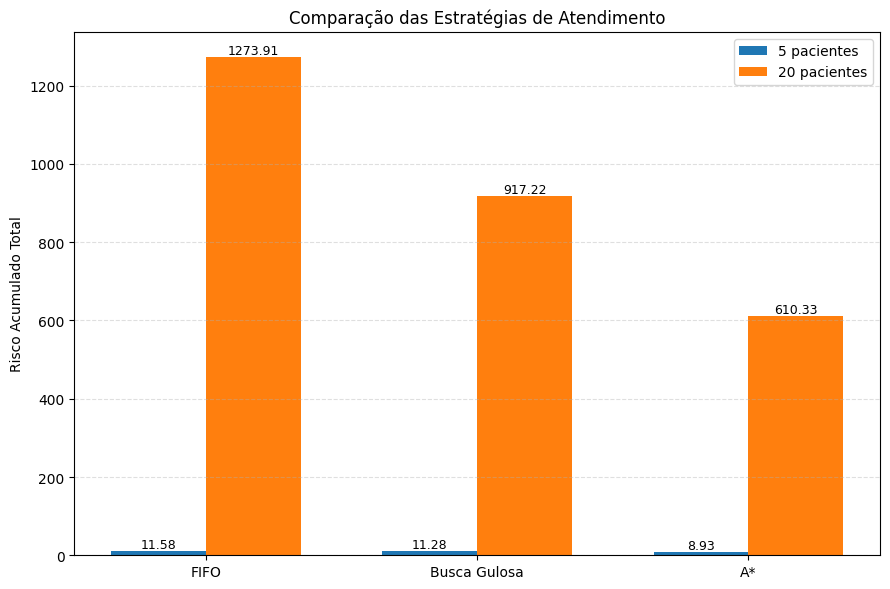

In [ ]:
estrategias = ["FIFO", "Busca Gulosa", "A*"]

riscos_5 = [
    calcular_risco_acumulado_total(fila_hospital_5),
    calcular_risco_acumulado_total(ordem_gulosa_5),
    calcular_risco_acumulado_total(ordem_final_5),
]

riscos_20 = [
    calcular_risco_acumulado_total(fila_hospital_20),
    calcular_risco_acumulado_total(ordem_gulosa_20),
    calcular_risco_acumulado_total(ordem_final_20),
]

x = np.arange(len(estrategias))
largura = 0.35

plt.figure(figsize=(9,6))

barras1 = plt.bar(x - largura/2, riscos_5, largura, label="5 pacientes")
barras2 = plt.bar(x + largura/2, riscos_20, largura, label="20 pacientes")

plt.xticks(x, estrategias)
plt.ylabel("Risco Acumulado Total")
plt.title("Comparação das Estratégias de Atendimento")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)

# Valores sobre as barras
for barras in [barras1, barras2]:
    for barra in barras:
        plt.text(
            barra.get_x() + barra.get_width()/2,
            barra.get_height(),
            f"{barra.get_height():.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.show()